Data Understanding and Visualization

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


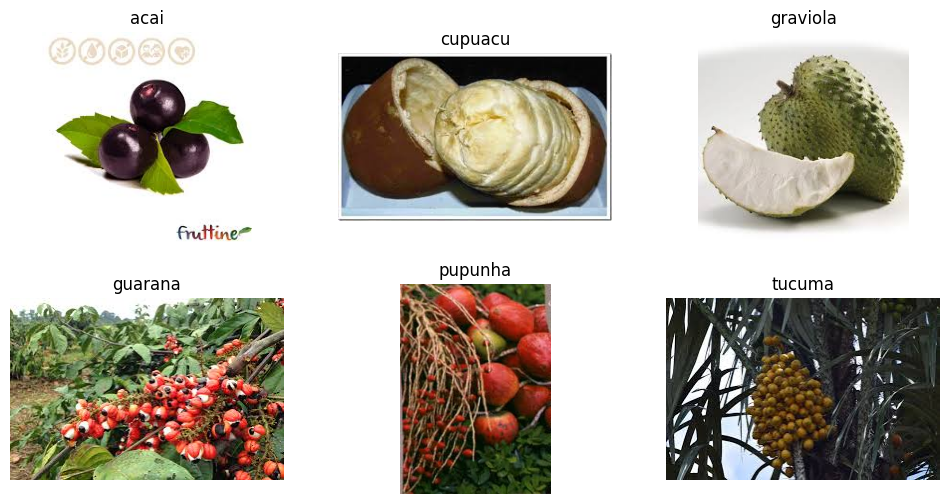

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = '/content/drive/MyDrive/Artificial-Intelligence-And-Machine-Learning-Materials/Week 5/FruitinAmazon/train'
classes = sorted(os.listdir(train_dir))

plt.figure(figsize=(12, 6))
for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.show()

Check for corrupted images

In [ ]:
import os
from PIL import Image

def clean_corrupted_images(directory):
    corrupted_count = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify() # Verify it is an image
            except (IOError, SyntaxError):
                os.remove(file_path)
                print(f"Removed corrupted image: {file_path}")
                corrupted_count += 1
    if corrupted_count == 0:
        print("No Corrupted Images Found.")

clean_corrupted_images(train_dir)

No Corrupted Images Found.


Loading and Preprocessing

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

img_height, img_width = 128, 128
batch_size = 16 # As per Task 4 instruction

# 1. Load Data
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/drive/MyDrive/Artificial-Intelligence-And-Machine-Learning-Materials/Week 5/FruitinAmazon/test',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'
)

# 2. Add Data Augmentation (Crucial to fix overfitting)
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

# 3. Apply Normalization and Augmentation [cite: 510, 511]
rescale = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (data_augmentation(rescale(x), training=True), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Found 30 files belonging to 6 classes.


In [ ]:
print(classes)
# It should print: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Implementation and Training

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Starting Transfer Learning Training...
Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.1208 - loss: 2.4424
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_fruit_model_transfer.h5



Epoch 1: finished saving model to best_fruit_model_transfer.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 577ms/step - accuracy: 0.1111 - loss: 2.6035 - val_accuracy: 0.1667 - val_loss: 2.4012
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.2024 - loss: 2.4579
Epoch 2: val_accuracy did not improve from 0.16667
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - accuracy: 0.1778 - loss: 2.4057 - val_accuracy: 0.1667 - val_loss: 2.2898
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.1290 - loss: 2.6935
Epoch 3: val_accuracy did not improve from 0.16667
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 0.1333 - loss: 2.5850 - val_accuracy: 0.1667 - val_loss: 2.1902
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.1312 - loss: 2.5137
Epoch 4: val_accuracy did not improve from 0.16667
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - accuracy: 0.1667 - loss: 2.4159 - val_accuracy: 0.1667 - val_loss: 2.1018
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.1499 - 

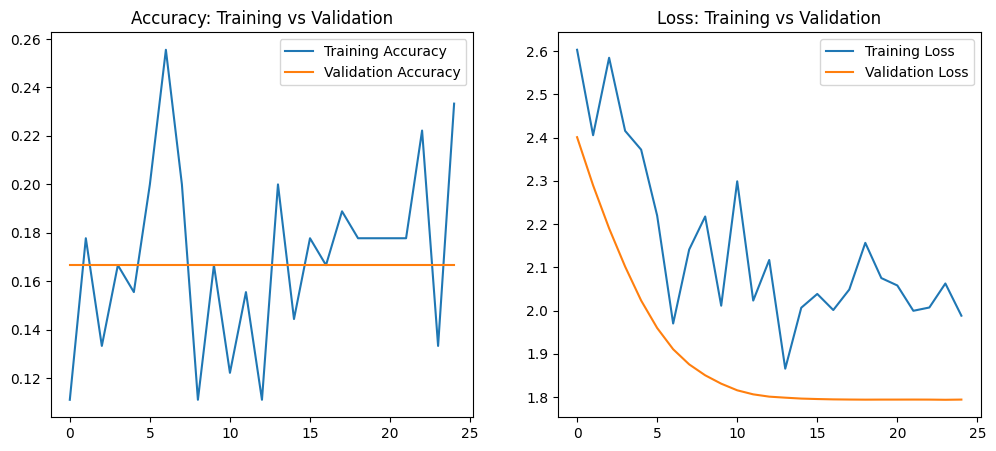

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Setup Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

# 2. Load Pre-trained Base (Transfer Learning)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze weights to prevent overfitting

# 3. Build the Final Model
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,          # Step 1: Augment image
    layers.Rescaling(1./255),   # Step 2: Normalize pixels (0-1)
    base_model,                 # Step 3: Feature extraction
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),        # Step 4: Prevent memorization
    layers.Dense(6, activation='softmax') # Step 5: 6 classes
])

# 4. Compile with a lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Define Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_fruit_model_transfer.h5', monitor='val_accuracy', save_best_only=True, verbose=1)

# 6. Training (25 Epochs)
print("Starting Transfer Learning Training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop, checkpoint]
)

# 7. Visualization
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy: Training vs Validation')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss: Training vs Validation')
plt.legend()
plt.show()

Evaluation and Classification Report

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate [cite: 519]
loss, acc = model.evaluate(val_ds)
print(f"Test Accuracy: {acc*100:.2f}%")

# Generate Classification Report [cite: 524]
y_true = []
y_pred = []

for x, y in val_ds:
    preds = model.predict(x)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(y.numpy())

print(classification_report(y_true, y_pred, target_names=classes))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1667 - loss: 1.7916 
Test Accuracy: 16.67%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
              precision    recall  f1-score   support

        acai       0.17      1.00      0.29         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
